<a href="https://colab.research.google.com/github/Sanjay227001/MachineLearning_projects/blob/main/DL_CIFAR_10_Object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

In [2]:
#configuring the path kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
#dataset api
!kaggle competitions download -c cifar-10

100% 715M/715M [00:36<00:00, 20.3MB/s]



In [4]:
!ls

cifar-10.zip  kaggle.json  sample_data


In [5]:
#extracting the compressed zip
from zipfile import ZipFile
dataset = 'cifar-10.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('Done')

Done


In [6]:
!ls

cifar-10.zip  sample_data	    test.7z   trainLabels.csv
kaggle.json   sampleSubmission.csv  train.7z


In [7]:
!pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 11.9 MB/s eta 0:00:00


In [8]:
import py7zr

archeive = py7zr.SevenZipFile('/content/train.7z', mode='r')
archeive.extractall()
archeive.close()

In [9]:
!ls

cifar-10.zip  sample_data	    test.7z  train.7z
kaggle.json   sampleSubmission.csv  train    trainLabels.csv


In [10]:
#importing the dependency
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split

In [11]:
filename = os.listdir('/content/train')

In [12]:
type(filename)

list

In [13]:
len(filename)

50000

In [14]:
print(filename[0:5])
print(filename[-5:])

['19539.png', '30043.png', '34633.png', '42624.png', '668.png']
['39916.png', '46507.png', '1004.png', '21113.png', '46617.png']


In [15]:
#Labels processing
labels_df = pd.read_csv('/content/trainLabels.csv')
labels_df.head()

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


In [16]:
labels_df.shape

(50000, 2)

In [17]:
labels_df[labels_df['id'] == 668]

,id,label
667,668,frog


In [18]:
labels_df.head(10)

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile
5,6,automobile
6,7,bird
7,8,horse
8,9,ship
9,10,cat


In [19]:
labels_df.tail(10)

,id,label
49990,49991,deer
49991,49992,bird
49992,49993,airplane
49993,49994,automobile
49994,49995,airplane
49995,49996,bird
49996,49997,frog
49997,49998,truck
49998,49999,automobile
49999,50000,automobile


In [20]:
labels_df['label'].value_counts()

,count
label,
frog,5000
truck,5000
deer,5000
automobile,5000
bird,5000
horse,5000
ship,5000
cat,5000
dog,5000


In [21]:
labels_dictionary = {'airplane':0,'automobile':1,'bird':2,'cat':3,'deer':4,'dog':5,'frog':6,'horse':7,'ship':8,'truck':9}
labes = [labels_dictionary[i] for i in labels_df['label']]

In [22]:
print(labes[0:5])
print(labes[-5:])

[6, 9, 9, 4, 1]
[2, 6, 9, 1, 1]


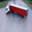

In [23]:
#displaying sample image
import cv2
from google.colab.patches import cv2_imshow

img=cv2.imread('/content/train/19539.png')
cv2_imshow(img)

In [24]:
labels_df[labels_df['id']==19539]

,id,label
19538,19539,truck


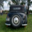

In [25]:
#displaying sample image
import cv2
from google.colab.patches import cv2_imshow

img=cv2.imread('/content/train/21113.png')
cv2_imshow(img)

In [26]:
labels_df[labels_df['id']==21113]

,id,label
21112,21113,automobile


In [27]:
id_list = list(labels_df['id'])

In [28]:
print(id_list[0:5])
print(id_list[-5:])

[1, 2, 3, 4, 5]
[49996, 49997, 49998, 49999, 50000]


Image processing

In [29]:
#convert img to numpy array
training_data_folder = '/content/train/'

data = []

for id in id_list:
  image = Image.open(training_data_folder + str(id) + '.png')
  image = np.array(image)
  data.append(image)

In [30]:
type(data)

list

In [31]:
len(data)

50000

In [32]:
type(data[0])

numpy.ndarray

In [33]:
data[0].shape

(32, 32, 3)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
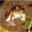

In [34]:
data[0]

In [35]:
#convert img and labels to numpy array
x = np.array(data)
y = np.array(labes)


In [36]:
print(x.shape)
print(y.shape)

(50000, 32, 32, 3)
(50000,)


Train Test split

In [37]:
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.2,random_state=3)

In [38]:
print(x.shape,X_train.shape,X_test.shape)

(50000, 32, 32, 3) (40000, 32, 32, 3) (10000, 32, 32, 3)


In [39]:
#scaling the data
X_train_scale = X_train/255
X_test_scale = X_test/255

In [40]:
X_train_scale

array([[[[1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        [[0.99215686, 0.99215686, 0.99215686],
         [0.99607843, 0.99607843, 0.99607843],
         [1.        , 1.        , 1.        ],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        [[0.99607843, 0.99607843, 0.99607843],
         [1.        , 1.        , 1.        ],
         [0.99607843, 0.99607843, 0.99607843],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        ...,

        [[0.99607843, 0.99607843, 0.99607843],
         [1.        , 1.        , 1.        ]

Building Neural Network

In [41]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [42]:
num_of_classes = 10

#setting layers

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(num_of_classes,activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
#compile NN
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['acc'])

In [44]:
#training NN
model.fit(X_train_scale,Y_train,validation_split = 0.1,epochs=10)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.2959 - loss: 1.9611 - val_acc: 0.3370 - val_loss: 1.8435
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.3505 - loss: 1.8186 - val_acc: 0.3618 - val_loss: 1.7907
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.3729 - loss: 1.7663 - val_acc: 0.3800 - val_loss: 1.7502
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.3834 - loss: 1.7323 - val_acc: 0.3840 - val_loss: 1.7299
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.3894 - loss: 1.7062 - val_acc: 0.3910 - val_loss: 1.7216
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.3977 - loss: 1.6868 - val_acc: 0.3845 - val_loss: 1.7320
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.4006 - loss: 1.6780 - val_acc: 0.3885 - val_loss: 1.7066
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.4056 - loss: 1.6632 - val_acc: 0.3980 - val_loss: 1.6890
Epoch 9/10
1125/1125 ━━━━━━━━━━━━━━━━━━━

In [45]:
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50

In [46]:
Convolutional_base = ResNet50(weights='imagenet',include_top=False,input_shape=(256,256,3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [47]:
Convolutional_base.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [48]:
from tensorflow.keras.layers import UpSampling2D

In [49]:
model = models.Sequential()
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(Convolutional_base)
model.add(layers.Flatten())
model.add(layers.BatchNormalization())
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(10,activation='softmax'))

In [50]:
from tensorflow.keras import optimizers

In [51]:
model.compile(optimizer=optimizers.RMSprop(learning_rate = 2e-5), loss='sparse_categorical_crossentropy', metrics=['acc'])

In [52]:
history = model.fit(X_train_scale, Y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 472s 372ms/step - acc: 0.4437 - loss: 1.6733 - val_acc: 0.7713 - val_loss: 0.8506
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 416s 370ms/step - acc: 0.7067 - loss: 0.9833 - val_acc: 0.8637 - val_loss: 0.5364
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 411s 365ms/step - acc: 0.8079 - loss: 0.7240 - val_acc: 0.9103 - val_loss: 0.3803
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 415s 369ms/step - acc: 0.8698 - loss: 0.5627 - val_acc: 0.9243 - val_loss: 0.3013
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 415s 369ms/step - acc: 0.9073 - loss: 0.4346 - val_acc: 0.9310 - val_loss: 0.2854
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 414s 368ms/step - acc: 0.9346 - loss: 0.3455 - val_acc: 0.9312 - val_loss: 0.2624
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 414s 368ms/step - acc: 0.9533 - loss: 0.2750 - val_acc: 0.9335 - val_loss: 0.2428
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 414s 368ms/step - acc: 0.9640 - loss: 0.2285 - val_acc: 0.9390 - val_loss: 0.2317
Epoch 9/

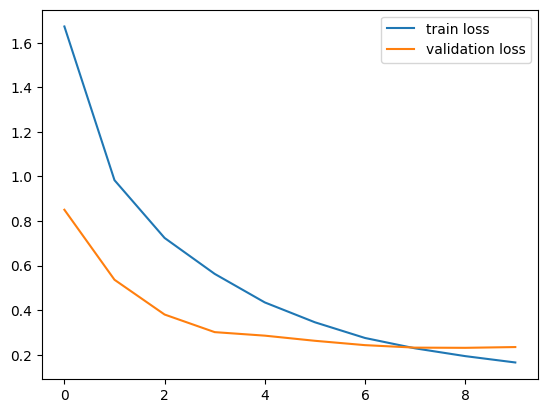

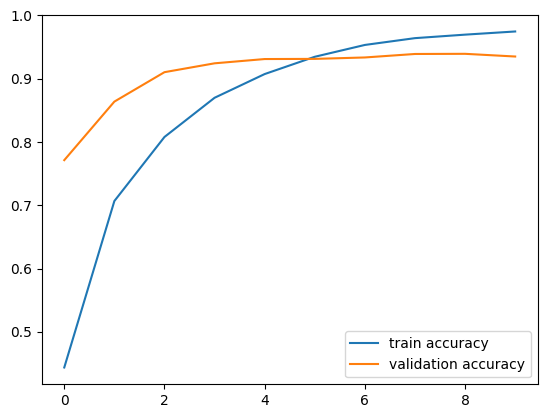

In [53]:
h = history

#plot the loss value

plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

#Plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

In [54]:
loss, accuracy = model.evaluate(X_test_scale, Y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 115ms/step - acc: 0.9403 - loss: 0.2148
Test Loss: 0.2147643119096756
Test Accuracy: 0.9402999877929688
